In [1]:
!hostname

gpue06.delta.ncsa.illinois.edu


In [2]:
import scanpy as sc
import scipy.sparse as sp
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.chdir('/projects/bhdw/asachan/methods/FIREFate/moscot')
import sys
import logging
import warnings

export_dir = "/work/hdd/bhdw/asachan/datasets_proj/SKM_ageing_human"
out_tmp = '/projects/bhdw/asachan/tmp'
figures_dir = '/projects/bhdw/asachan/figs/icml_2026'

In [4]:
pd.set_option('mode.string_storage', 'python')

## Load preprocessed ATAC and RNA AnnData

Both h5ads are expected to already have raw counts in `.X`, `obs.sample`, `obs.age`, and the embeddings the GW solver consumes (`obsm.X_lsi` for ATAC, `obsm.X_pca` for RNA). The earlier LSI / PCA preprocessing cells have been moved out of this notebook — re-run them upstream once if needed.

In [5]:
atac_file = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/atac_objects/atac_fiber/atac_female_type2.h5ad'
adata_atac = sc.read_h5ad(atac_file)

In [6]:
# add age as categorical
adata_atac.obs["age_categorical"] = adata_atac.obs["age"].astype("category")

In [7]:
rna_file = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad'
adata_rna = sc.read_h5ad(rna_file)

# Solve quadratic Gromov-Wasserstein OT

If the per-sample artifacts under `/projects/bhdw/asachan/tmp/T_npy_sample_matched/` (`T_*.npy` + `src_obs_*.npy` + `tgt_obs_*.npy`) are already on disk, skip the next three cells (the solver loop and its top-1 / eff-k QC, plus the disk save) and jump straight to the bridge cell at the start of the next section — it loads `T_per_sample` from disk if it isn't already in memory.

In [8]:
samples = sorted(adata_atac.obs["sample"].unique().tolist())
print("samples:", samples)

samples: ['OM6', 'OM9', 'YM2']


In [ ]:
import numpy as np, pathlib
from moscot.problems.cross_modality import TranslationProblem

def solve_one_sample(s, a_s, r_s, eps=1e-3, attempt=1):
    tp_s = TranslationProblem(adata_src=a_s, adata_tgt=r_s)
    tp_s = tp_s.prepare(
        src_attr={"attr": "obsm", "key": "X_lsi"},
        tgt_attr={"attr": "obsm", "key": "X_pca"},
    )
    tp_s = tp_s.solve(
        epsilon       = eps,
        alpha         = 1.0,
        scale_cost    = "mean",
        max_iterations= 10_000,                # ↑ from 2000 (outer GW)
        min_iterations= 50,
        threshold     = 1e-3,
        linear_solver_kwargs={
            "max_iterations": 20_000,          # ↑ from 5000 (inner Sinkhorn)
            "lse_mode": True,
            "threshold": 1e-3,
        },
    )
    (_, prob), = tp_s.problems.items()
    return tp_s, prob

T_per_sample, conv = {}, {}
for s in samples:
    a_s = adata_atac[adata_atac.obs["sample"] == s].copy()
    r_s = adata_rna [adata_rna .obs["sample"] == s].copy()
    print(f"\n{s}: ATAC {a_s.n_obs} → RNA {r_s.n_obs}")

    tp_s, prob = solve_one_sample(s, a_s, r_s, eps=1e-3)

    # if YM2 still doesn't converge, retry once with looser eps
    if not bool(prob.solution.converged):
        print(f"  {s} did NOT converge at eps=1e-3, retrying eps=2e-3")
        tp_s, prob = solve_one_sample(s, a_s, r_s, eps=2e-3)

    T_per_sample[s] = np.asarray(prob.solution.transport_matrix)
    conv[s] = bool(prob.solution.converged)
    print(f"  cost={prob.solution.cost:.4f}  converged={conv[s]}  T={T_per_sample[s].shape}")

In [ ]:
import numpy as np
for s, T in T_per_sample.items():
    Tc = T / T.sum(0, keepdims=True)
    H  = -(Tc * np.log(Tc + 1e-30)).sum(0)
    eff_k = np.exp(H)
    top1  = Tc.max(0)
    print(f"{s}: top1_med={np.median(top1):.3f}  eff_k_med={np.median(eff_k):.0f}  "
          f"converged={conv[s]}  T_sum={T.sum():.4f}")

In [ ]:
out = pathlib.Path("/projects/bhdw/asachan/tmp/T_npy_sample_matched")
out.mkdir(parents=True, exist_ok=True)

for s, T in T_per_sample.items():
    np.save(out / f"T_{s}.npy", T)
    np.save(out / f"src_obs_{s}.npy",
            adata_atac.obs.index[adata_atac.obs["sample"] == s].astype(str).values)
    np.save(out / f"tgt_obs_{s}.npy",
            adata_rna .obs.index[adata_rna .obs["sample"] == s].astype(str).values)

print("artefacts in:", out)

## From OT pairing to peak → gene: barycentric projection + P2G + volcano

The cells below transport ATAC peak accessibility onto every RNA cell using the per-sample GW couplings from the previous section, build the multi-modal `mome` MuData, subset RNA to MaxToki vocab, compute the distance-decay peak→gene matrix `P2G`, and finish with the young-vs-old volcano on per-gene transported peak mass. The last cell saves a single **prep bundle** (`atac_rna_pairing_skm_prep/`) that `maxtoki_multimodal_prep.ipynb` consumes.

In [9]:
# Bridge: ensure T_per_sample / transports / obs_src_per_pair / obs_tgt_per_pair
# are in scope so the barycentric cells below work whether the OT-solve cell
# just ran (T_per_sample already in memory) OR this notebook section is being
# run on its own from the per-sample artifacts saved under T_dir
# (T_{s}.npy + src_obs_{s}.npy + tgt_obs_{s}.npy, written by cell 35).
import os, pathlib, pandas as pd, numpy as np

T_dir = pathlib.Path(os.environ.get(
    "FIREFATE_T_DIR",
    "/projects/bhdw/asachan/tmp/T_npy_sample_matched",
))

if "T_per_sample" not in dir():
    T_per_sample        = {}
    obs_src_per_sample  = {}
    obs_tgt_per_sample  = {}
    for path in sorted(T_dir.glob("T_*.npy")):
        s = path.stem.replace("T_", "")
        T_per_sample[s]       = np.load(path)
        obs_src_per_sample[s] = np.load(T_dir / f"src_obs_{s}.npy", allow_pickle=True)
        obs_tgt_per_sample[s] = np.load(T_dir / f"tgt_obs_{s}.npy", allow_pickle=True)
    if not T_per_sample:
        raise FileNotFoundError(
            f"no T_*.npy artifacts under {T_dir}. Run the OT-solve cell above "
            f"or set FIREFATE_T_DIR to a directory that has them."
        )
    print(f"loaded T_per_sample from {T_dir}: {sorted(T_per_sample)}")
else:
    # OT solve just ran in this kernel -- adata still has the source rows in
    # the same order the solver consumed.
    obs_src_per_sample = {s: adata_atac.obs.index[adata_atac.obs["sample"] == s].astype(str).values
                          for s in T_per_sample}
    obs_tgt_per_sample = {s: adata_rna .obs.index[adata_rna .obs["sample"] == s].astype(str).values
                          for s in T_per_sample}
    print(f"using in-memory T_per_sample: {sorted(T_per_sample)}")

transports       = {(s, s): T_per_sample[s] for s in sorted(T_per_sample)}
obs_src_per_pair = {(s, s): pd.DataFrame(index=pd.Index(np.asarray(obs_src_per_sample[s]).astype(str), name="atac_obs"))
                    for s in sorted(T_per_sample)}
obs_tgt_per_pair = {(s, s): pd.DataFrame(index=pd.Index(np.asarray(obs_tgt_per_sample[s]).astype(str), name="rna_obs"))
                    for s in sorted(T_per_sample)}

human_genome_path = os.environ.get("HUMAN_GENOME_PATH",
                       "/work/hdd/bgdb/asachan/datasets_proj/human_genome_files")
out_tmp           = os.environ.get("OUT_TMP",
                       "/projects/bhdw/asachan/tmp")

print(f"transports: {len(transports)} sample blocks "
      f"({list(transports.keys())})")
print(f"human_genome_path = {human_genome_path}")
print(f"out_tmp           = {out_tmp}")

loaded T_per_sample from /projects/bhdw/asachan/tmp/T_npy_sample_matched: ['OM6', 'OM9', 'YM2']
transports: 3 sample blocks ([('OM6', 'OM6'), ('OM9', 'OM9'), ('YM2', 'YM2')])
human_genome_path = /work/hdd/bgdb/asachan/datasets_proj/human_genome_files
out_tmp           = /projects/bhdw/asachan/tmp


#### Pull soft peak accessibility onto every RNA cell — **sample-stratified** so each RNA cell receives peak mass only from same-donor ATAC. The per-sample GW solves already enforce this on the row blocks; this section assembles the global coupling correctly and adds a defensive sample-mask so cross-sample mass is exactly zero.

In [10]:
import numpy as np, scipy.sparse as sp

# Assemble the global (n_atac, n_rna) coupling by placing each per-sample
# transport block at the correct (row, col) positions on the global grid.
# obs_src_per_pair[(src,tgt)].index / obs_tgt_per_pair[(src,tgt)].index give
# the exact ATAC/RNA cell IDs at the rows/cols of each T block — works whether
# T is compact (n_src_s, n_tgt_s) or full-width.
atac_pos = {idx: i for i, idx in enumerate(adata_atac.obs.index.astype(str))}
rna_pos  = {idx: i for i, idx in enumerate(adata_rna .obs.index.astype(str))}

T_full = np.zeros((adata_atac.n_obs, adata_rna.n_obs), dtype=np.float32)
for (src_b, tgt_b), T in transports.items():
    src_obs = obs_src_per_pair[(src_b, tgt_b)].index.astype(str)
    tgt_obs = obs_tgt_per_pair[(src_b, tgt_b)].index.astype(str)
    if T.shape != (len(src_obs), len(tgt_obs)):
        raise ValueError(
            f"{src_b}->{tgt_b}: T {T.shape} != ({len(src_obs)},{len(tgt_obs)})"
        )
    src_i = np.fromiter((atac_pos[i] for i in src_obs), dtype=np.int64, count=len(src_obs))
    tgt_i = np.fromiter((rna_pos [i] for i in tgt_obs), dtype=np.int64, count=len(tgt_obs))
    T_full[np.ix_(src_i, tgt_i)] = T.astype(np.float32)
    print(f"  placed {src_b} -> {tgt_b}  block={T.shape}")

# SAMPLE-stratify (defensive) — ensures each RNA cell receives peak mass ONLY
# from ATAC cells of the *same donor*.  Per-sample GW solves already enforce
# this; this step is a no-op when the export is clean and a hard guard
# otherwise.  This is what makes a query cell's chromatin bias come from its
# own donor's ATAC even when the perturb pipeline pools across donors of the
# same age (e.g. all O80 cells from donor A and donor B).
atac_sample = adata_atac.obs["sample"].astype(str).values
rna_sample  = adata_rna .obs["sample"].astype(str).values

sample_match = atac_sample[:, None] == rna_sample[None, :]
n_xs = int(((T_full > 0) & ~sample_match).sum())
T_strat = np.where(sample_match, T_full, 0.0).astype(np.float32)
print(f"  zeroed {n_xs} cross-sample T entries (should be 0 if OT was per-sample)")

col_sum  = T_strat.sum(0, keepdims=True)
n_orphan = int((col_sum.ravel() == 0).sum())
print(f"  RNA cells with no same-sample ATAC source: {n_orphan} / {T_strat.shape[1]}")
T_col    = T_strat / np.where(col_sum > 0, col_sum, 1.0)        # column-stochastic

# soft peak matrix per RNA cell (raw Tn5 counts, not TF-IDF)
X_peak      = adata_atac.X.toarray() if sp.issparse(adata_atac.X) else adata_atac.X
X_peaks_rna = T_col.T @ X_peak                                   # (n_rna, n_peaks)

adata_rna.obsm["X_peaks_inferred"] = X_peaks_rna.astype(np.float32)
print("inferred peaks per RNA cell:", X_peaks_rna.shape,
      "  mean nnz / cell:", float((X_peaks_rna > 0).sum(1).mean()))

  placed OM6 -> OM6  block=(243, 722)
  placed OM9 -> OM9  block=(2238, 1278)
  placed YM2 -> YM2  block=(3349, 1989)
  zeroed 0 cross-sample T entries (should be 0 if OT was per-sample)
  RNA cells with no same-sample ATAC source: 0 / 3989
inferred peaks per RNA cell: (3989, 27649)   mean nnz / cell: 26290.237653547254


In [11]:
import pandas as pd
# Mass each RNA cell receives, grouped by donor sample.  Within a donor we
# expect roughly uniform mean mass; orphans (mass == 0) should be 0 by
# construction since each sample has its own ATAC cells. (om6 just has low rna cells and this mean depends on 1/n_of_cells)
print(pd.DataFrame({
    "rna_sample":    rna_sample,
    "received_mass": col_sum.ravel(),
}).groupby("rna_sample")["received_mass"].agg(["mean", "std", "min", "max", "count"]))

                mean       std       min       max  count
rna_sample                                               
OM6         0.001385  0.000002  0.001384  0.001392    722
OM9         0.000782  0.000002  0.000752  0.000786   1278
YM2         0.000503  0.000004  0.000502  0.000599   1989


#### is the transition probability too diffused or does it still capture geometrical structure above uniform coupling?
#### also fewer atac-neighbours

In [12]:
import numpy as np, pandas as pd
T_col_n = T_strat / np.where(col_sum > 0, col_sum, 1.0)
H       = -(T_col_n * np.log(T_col_n + 1e-30)).sum(0)
df = pd.DataFrame({
    "sample": rna_sample,
    "top1":   T_col_n.max(0),
    "eff_k":  np.exp(H),
})
print(df.groupby("sample").agg(["median", lambda x: np.percentile(x, 95)]))

            top1                 eff_k            
          median <lambda_0>     median  <lambda_0>
sample                                            
OM6     0.598465   0.999960   3.167665   30.764732
OM9     0.181309   0.537463  27.169317  103.766083
YM2     0.106789   0.501286  63.279961  209.356628


## Multi-ome data

In [13]:
import muon as mu
# Import a module with ATAC-seq-related functions
from muon import atac as ac

/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [14]:
# ---- (cell 20 replacement) build MuData from raw soft peaks -----------
import mudata as mu, anndata as ad

peaks    = adata_atac.var_names.to_list()
peak_var = adata_atac.var[["chrom","start","end"]].copy() \
           if {"chrom","start","end"}.issubset(adata_atac.var.columns) else None
if peak_var is None:
    parsed = [p.replace(":", "-").split("-") for p in peaks]
    peak_var = pd.DataFrame(parsed, columns=["chrom","start","end"], index=peaks) \
                 .astype({"start": int, "end": int})

rna  = ad.AnnData(
    X=adata_rna.X if sp.issparse(adata_rna.X) else sp.csr_matrix(adata_rna.X),
    obs=adata_rna.obs.copy(), var=adata_rna.var.copy(),
    obsm={"X_pca": adata_rna.obsm["X_pca"]},
)
atac = ad.AnnData(
    X=sp.csr_matrix(X_peaks_rna),
    obs=adata_rna.obs.copy(), var=peak_var,
)
atac.var_names = peaks
mome = mu.MuData({"rna": rna, "atac": atac})

# ---- (cell 21 replacement) TF-IDF in-place on mome ATAC ---------------
def tfidf(M, scale=1e4):
    M = M.tocsr() if sp.issparse(M) else sp.csr_matrix(M)
    rs  = np.asarray(M.sum(1)).ravel() + 1e-12
    cs  = np.asarray(M.sum(0)).ravel() + 1e-12
    idf = np.log1p(M.shape[0] / cs)
    Mn  = sp.diags(scale / rs) @ M @ sp.diags(idf)
    return Mn.log1p()

mome["atac"].layers["tfidf"] = tfidf(mome["atac"].X)
print(mome)

/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 3989 × 76004
  2 modalities
    rna:	3989 × 48355
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
      var:	'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      obsm:	'X_pca'
    atac:	3989 × 27649
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
      var:	'chrom', 'start', 'end'
      layers:	'tfidf'


#### Subset the rna to MaxToki vocab

In [15]:
import pandas as pd, pyranges as pr, numpy as np

# 1. symbol → ENSG from the same GTF you used for TSS lookup
gtf = pr.read_gtf(f"{human_genome_path}/gencode.v46.annotation.gtf").df
gtf = gtf[gtf.Feature == "gene"][["gene_name", "gene_id"]].drop_duplicates("gene_name")
gtf["gene_id_clean"] = gtf["gene_id"].str.split(".").str[0]    # strip ENSG version
sym2ensg = dict(zip(gtf["gene_name"].astype(str), gtf["gene_id_clean"]))
print(f"GTF mappings: {len(sym2ensg)} symbol→ENSG")

# 2. attach ENSG to mome["rna"].var
syms = mome["rna"].var_names.astype(str)
mome["rna"].var["ensg"] = [sym2ensg.get(s, None) for s in syms]

n_total   = mome["rna"].n_vars
n_mapped  = mome["rna"].var["ensg"].notna().sum()
print(f"{n_mapped}/{n_total} symbols mapped to ENSG  ({n_mapped/n_total:.1%})")

GTF mappings: 61471 symbol→ENSG
29718/48355 symbols mapped to ENSG  (61.5%)


In [16]:
import json, numpy as np, pandas as pd

# 1. load MaxToki vocab
with open("/projects/bhdw/asachan/methods/maxtoki-perturb/src/maxtoki_mlx/resources/token_dictionary.json") as f:
    vocab = json.load(f)

# strip special tokens to leave only ENSG entries
ensg_to_token = {k: v for k, v in vocab.items() if k.startswith("ENSG")}
print(f"vocab tokens: {len(vocab)} total, {len(ensg_to_token)} ENSG-keyed")

# 2. attach token index to mome["rna"].var
mome["rna"].var["maxtoki_token"] = (
    mome["rna"].var["ensg"].map(ensg_to_token).astype("Int64")  # nullable int
)

n_in_vocab = mome["rna"].var["maxtoki_token"].notna().sum()
print(f"vars with MaxToki token: {n_in_vocab} / {mome['rna'].n_vars} "
      f"({n_in_vocab / mome['rna'].n_vars:.1%})")

vocab tokens: 20277 total, 20271 ENSG-keyed
vars with MaxToki token: 18470 / 48355 (38.2%)


In [17]:
import numpy as np

mask = mome["rna"].var["maxtoki_token"].notna()
print(f"keeping {mask.sum()} / {mome['rna'].n_vars} genes")

# rebuild MuData with subsetted RNA modality, ATAC unchanged
import mudata as mu
rna_sub = mome["rna"][:, mask.values].copy()
rna_sub.var["maxtoki_token"] = rna_sub.var["maxtoki_token"].astype(int)
rna_sub = rna_sub[:, np.argsort(rna_sub.var["maxtoki_token"].values)].copy()  # sort by token id


keeping 18470 / 48355 genes


In [19]:
rna_sub.var["ensembl_id"] = rna_sub.var['ensg']        # if ENSGs are the index

In [21]:
mome["rna"].var["ensembl_id"] = mome["rna"].var['ensg']        # if ENSGs are the index

In [22]:
# After your subsetting block, before saving
original_rna = mome["rna"]   # whatever the pre-mask version is

# Match by gene id (since order may differ)
gene_to_idx = {g: i for i, g in enumerate(original_rna.var["ensembl_id"].astype(str))}
src_idx = [gene_to_idx[g] for g in rna_sub.var["ensembl_id"].astype(str)]

# Port counts (and any other layer you need)
for layer_name in ("counts",):    # add "lognorm", "spliced", etc. if needed
    if layer_name in original_rna.layers:
        rna_sub.layers[layer_name] = original_rna.layers[layer_name][:, src_idx].copy()
        print(f"[port] {layer_name}: {rna_sub.layers[layer_name].shape}")

mome = mu.MuData({"rna": rna_sub, "atac": mome["atac"]})
print(mome)

MuData object with n_obs × n_vars = 3989 × 46119
  2 modalities
    rna:	3989 × 18470
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
      var:	'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ensg', 'maxtoki_token', 'ensembl_id'
      obsm:	'X_pca'
    atac:	3989 × 27649
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
      var:	'chrom', 'start', 'end'
      layers:	'tfidf'


/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [24]:
#write mudata to file
mome.write_h5mu('multiome_atac_rna.h5mu')

/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


# Peak to gene (TSS +- 250kb for long-range CRE-peak capture & TF-Motif scan in age-specific open chromatin)

#### TSS finder

In [23]:
import numpy as np, pandas as pd, scipy.sparse as sp, pyranges as pr
from tqdm.auto import tqdm

# TSS lookup
gtf = pr.read_gtf(f"{human_genome_path}/gencode.v46.annotation.gtf").df
gtf = gtf[gtf.Feature == "gene"][["gene_id","Chromosome","Start","End","Strand"]]
gtf["TSS"]     = np.where(gtf.Strand == "+", gtf.Start, gtf.End)
gtf["gene_id"] = gtf["gene_id"].str.split(".").str[0]
tss = gtf.drop_duplicates("gene_id").set_index("gene_id")[["Chromosome","TSS"]]

atac, rna = mome["atac"], mome["rna"]
genes_e   = rna.var["ensg"].astype(str).values
peak_mid  = ((atac.var["start"].astype(int) + atac.var["end"].astype(int)) // 2).values
peak_chr  = atac.var["chrom"].astype(str).values
peak_by_chr = {ch: (np.where(peak_chr==ch)[0], peak_mid[peak_chr==ch])
               for ch in np.unique(peak_chr)}

WIN, SCALE = 250_000, 50_000 # distance -decay based likelihood
present = np.isin(genes_e, tss.index.values)
print(f"{present.sum():,}/{len(genes_e):,} genes have TSS")

cand_p, cand_g, cand_w = [], [], []
for gi in tqdm(np.where(present)[0], desc="P2G distance-decay"):
    e = genes_e[gi]
    chrom, t = tss.at[e, "Chromosome"], int(tss.at[e, "TSS"])
    if chrom not in peak_by_chr: continue
    p_idx, p_mid = peak_by_chr[chrom]
    d = np.abs(p_mid - t)
    m = d <= WIN
    if m.any():
        cand_p.append(p_idx[m])
        cand_g.append(np.full(m.sum(), gi, dtype=np.int64))
        cand_w.append(np.exp(-d[m] / SCALE).astype(np.float32))

cand_p = np.concatenate(cand_p); cand_g = np.concatenate(cand_g); cand_w = np.concatenate(cand_w)
P2G = sp.csr_matrix((cand_w, (cand_p, cand_g)), shape=(atac.n_vars, rna.n_vars))
print("P2G:", P2G.shape, "nnz:", P2G.nnz)
sp.save_npz(f"{out_tmp}/P2G.npz", P2G)

18,470/18,470 genes have TSS


P2G distance-decay: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18470/18470 [00:00<00:00, 68826.03it/s]


P2G: (27649, 18470) nnz: 205002


In [25]:
import numpy as np, scipy.sparse as sp, pandas as pd
import matplotlib.pyplot as plt

X_open = mome["atac"].X.toarray() if sp.issparse(mome["atac"].X) else mome["atac"].X
# (n_cells, n_peaks) @ (n_peaks, n_genes) = (n_cells, n_genes) regulatory mass
reg_mass = X_open @ P2G                                                      # dense

ages = mome["rna"].obs["age_categorical"].astype(str).values
mask80 = ages == "80"; mask34 = ages == "34"

mean80 = reg_mass[mask80].mean(0); mean34 = reg_mass[mask34].mean(0)
log2fc = np.log2((mean80 + 1e-6) / (mean34 + 1e-6))

# rough significance via Welch t-test
from scipy.stats import ttest_ind
_, pvals = ttest_ind(reg_mass[mask80], reg_mass[mask34], axis=0, equal_var=False)
nlogp = -np.log10(np.clip(pvals, 1e-50, 1))


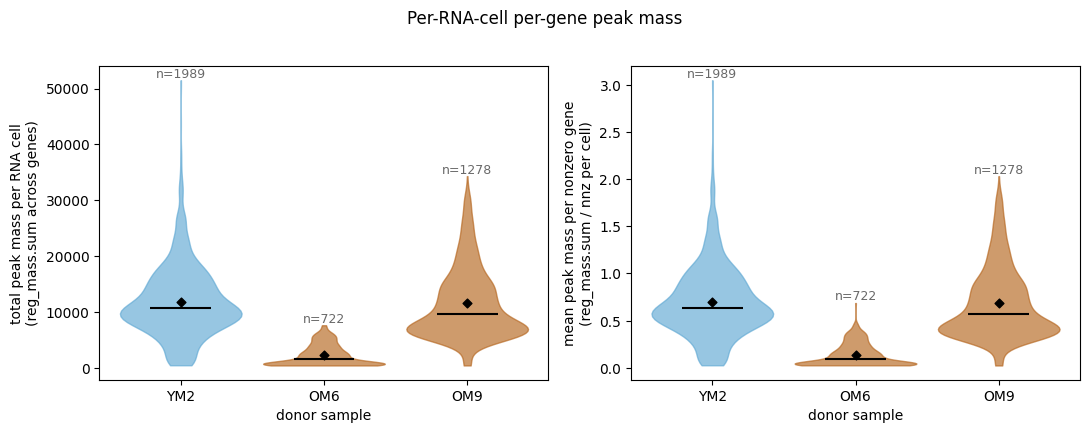

In [27]:
# Per-RNA-cell per-gene peak mass across donor samples - the signal that
# `build_attn_keep_mask` actually filters on (it gates each gene-token by
# reg_mass[c, g] >= sample_threshold). Two cell-level summaries that are NOT
# 1/n_rna artifacts:
#   (a) total peak mass per cell        = reg_mass.sum(axis=1)
#   (b) mean peak mass per nonzero gene = reg_mass.sum / nnz per cell
import matplotlib.pyplot as plt
import numpy as np, pandas as pd, scipy.sparse as sp

RM             = reg_mass if sp.issparse(reg_mass) else sp.csr_matrix(reg_mass)
total_per_cell = np.asarray(RM.sum(axis=1)).ravel()
nnz_per_cell   = np.asarray((RM > 0).sum(axis=1)).ravel()
mean_per_gene  = np.where(nnz_per_cell > 0,
                          total_per_cell / np.maximum(nnz_per_cell, 1),
                          0.0)

samples_ord = sorted(np.unique(rna_sample),
                     key=lambda s: ({"Y": 0, "M": 1, "O": 2}.get(s[0], 9), s))
palette = {"Y": "#5fa8d3", "M": "#9c89b8", "O": "#b5651d"}
colors  = [palette.get(s[0], "grey") for s in samples_ord]

df = pd.DataFrame({"sample": rna_sample,
                   "total": total_per_cell,
                   "mean_per_gene": mean_per_gene})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, col, ylab in [
    (axes[0], "total",
     "total peak mass per RNA cell\n(reg_mass.sum across genes)"),
    (axes[1], "mean_per_gene",
     "mean peak mass per nonzero gene\n(reg_mass.sum / nnz per cell)"),
]:
    data = [df.loc[df["sample"] == s, col].values for s in samples_ord]
    parts = ax.violinplot(data, showmedians=True, showextrema=False, widths=0.85)
    for pc, c in zip(parts["bodies"], colors):
        pc.set_facecolor(c); pc.set_edgecolor(c); pc.set_alpha(0.65)
    parts["cmedians"].set_color("k")
    for i, s in enumerate(samples_ord, start=1):
        sub = df[col][df["sample"] == s]
        ax.scatter([i], [sub.mean()], color="k", marker="D", s=20, zorder=5)
        ax.annotate(f"n={len(sub)}", (i, sub.max()),
                    ha="center", va="bottom", fontsize=9, color="dimgray")
    ax.set_xticks(range(1, len(samples_ord) + 1))
    ax.set_xticklabels(samples_ord)
    ax.set_ylabel(ylab)
    ax.set_xlabel("donor sample")

fig.suptitle("Per-RNA-cell per-gene peak mass",
             y=1.02)
plt.tight_layout()
plt.show()

      gene    log2fc  -log10(p) side
0   SLC2A2  1.635320       50.0  80↑
1    PAGE1  2.533881       50.0  80↑
2    MYCT1  1.603424       50.0  80↑
3      PRL  0.975555       50.0  80↑
4     MYH8  1.000580       50.0  80↑
5  POLDIP2 -0.823842       50.0  34↑
6    SARM1 -0.824306       50.0  34↑
7     RBM5 -0.596491       50.0  34↑
8     RBM6 -0.703868       50.0  34↑
9      AK2 -0.814987       50.0  34↑


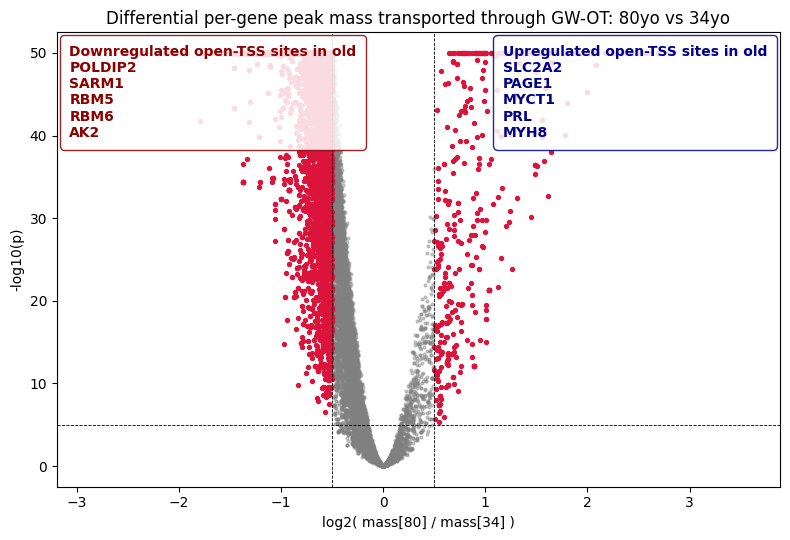

In [29]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

hits = (np.abs(log2fc) > 0.5) & (pvals < 1e-5)

N = 5
nlogp_safe = np.where(hits, nlogp, -np.inf)
top_up   = np.argsort(np.where(log2fc > 0, nlogp_safe, -np.inf))[::-1][:N]
top_down = np.argsort(np.where(log2fc < 0, nlogp_safe, -np.inf))[::-1][:N]

top_df = pd.DataFrame({
    "gene":      np.concatenate([mome["rna"].var_names.values[top_up],
                                 mome["rna"].var_names.values[top_down]]),
    "log2fc":    np.concatenate([log2fc[top_up],   log2fc[top_down]]),
    "-log10(p)": np.concatenate([nlogp[top_up],    nlogp[top_down]]),
    "side":      ["80↑"] * N + ["34↑"] * N,
})
print(top_df)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(log2fc, nlogp, s=4, alpha=0.4, c="grey")
ax.scatter(log2fc[hits], nlogp[hits], s=8, c="crimson")
ax.axhline(-np.log10(1e-5), ls="--", c="k", lw=0.6)
ax.axvline( 0.5, ls="--", c="k", lw=0.6); ax.axvline(-0.5, ls="--", c="k", lw=0.6)
ax.set_xlabel("log2( mass[80] / mass[34] )")
ax.set_ylabel("-log10(p)")
ax.set_title("Differential per-gene peak mass transported through GW-OT: 80yo vs 34yo")

# legend-style text boxes inside the plot
def gene_box(genes, color, header, loc):
    text = header + "\n" + "\n".join(genes)
    box  = AnchoredText(
        text, loc=loc, prop=dict(color=color, fontsize=10, fontweight="bold"),
        frameon=True, borderpad=0.5, pad=0.4,
    )
    box.patch.set_boxstyle("round,pad=0.3")
    box.patch.set_edgecolor(color)
    box.patch.set_facecolor("white")
    box.patch.set_alpha(0.85)
    return box

ax.add_artist(gene_box(
    [mome["rna"].var_names[gi] for gi in top_down],
    color="darkred",  header="Downregulated open-TSS sites in old", loc="upper left"
))
ax.add_artist(gene_box(
    [mome["rna"].var_names[gi] for gi in top_up],
    color="darkblue", header="Upregulated open-TSS sites in old",  loc="upper right"
))

plt.tight_layout()
fig.savefig(f"{out_tmp}/volcano_p2g_age.svg", format="svg", bbox_inches="tight")
plt.show()

In [31]:
# Save the prep bundle that maxtoki_multimodal_prep.ipynb consumes. Single
# contract: rna_sub.h5ad (vocab-subset RNA, sorted by token id), mome.h5mu
# (rna + atac with X_peaks_rna), the three sparse arrays, and a manifest.
import json, scipy.sparse as sp
from pathlib import Path

PREP_DIR = Path(out_tmp) / "atac_rna_pairing_skm_prep"
PREP_DIR.mkdir(parents=True, exist_ok=True)

# 1. AnnData inputs to MaxToki RVE tokenization
rna_sub.write_h5ad(PREP_DIR / "rna_sub.h5ad")          # vocab-subset RNA, sorted by maxtoki_token
mome.write_h5mu   (PREP_DIR / "mome.h5mu")             # MuData (rna + atac with X_peaks_rna)

# 2. Sparse arrays the sparsity-bias builder needs
sp.save_npz(PREP_DIR / "P2G.npz",         P2G.tocsr())
sp.save_npz(PREP_DIR / "X_peaks_rna.npz", sp.csr_matrix(X_peaks_rna))
sp.save_npz(PREP_DIR / "reg_mass.npz",    sp.csr_matrix(reg_mass))

# 3. Manifest — recipe + provenance
prep_manifest = {
    "format_version": 1,
    "n_cells": int(rna_sub.n_obs),
    "n_genes": int(rna_sub.n_vars),
    "n_peaks": int(mome["atac"].n_vars),
    "ot_pairing": {
        "stratification": "sample (per-donor GW couplings, sample-block-diagonal)",
        "T_dir":          str(out_tmp),
    },
    "p2g": {
        "win_bp":   250_000,
        "scale_bp": 50_000,
        "decay":    "exp(-d/scale)",
        "shape":    list(P2G.shape),
        "nnz":      int(P2G.nnz),
    },
    "files": {
        "rna_sub":     "rna_sub.h5ad     -- vocab-subset RNA AnnData, sorted by maxtoki_token; obs.age_categorical, obs.sample; var.ensg, var.maxtoki_token, var.ensembl_id",
        "mome":        "mome.h5mu        -- MuData (rna + atac with X_peaks_rna; tfidf in atac.layers)",
        "P2G":         "P2G.npz          -- csr (n_peaks, n_genes_rna_sub) distance-decay weights",
        "X_peaks_rna": "X_peaks_rna.npz  -- csr (n_cells, n_peaks) per-RNA-cell soft peak accessibility",
        "reg_mass":    "reg_mass.npz     -- csr (n_cells, n_genes_rna_sub) per-gene peak mass per cell (= X_peaks_rna @ P2G)",
    },
}
(PREP_DIR / "manifest.json").write_text(json.dumps(prep_manifest, indent=2))
print(f"prep bundle: {PREP_DIR}")
for p in sorted(PREP_DIR.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size/1e6:.1f} MB)")

/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


prep bundle: /projects/bhdw/asachan/tmp/atac_rna_pairing_skm_prep
  P2G.npz  (0.8 MB)
  X_peaks_rna.npz  (889.3 MB)
  manifest.json  (0.0 MB)
  mome.h5mu  (2601.5 MB)
  reg_mass.npz  (604.2 MB)
  rna_sub.h5ad  (77.8 MB)
